In [1]:
#import kaggle
import os
import pandas as pd

# 1. Definimos las columnas (C-MAPSS estándar)
columnas = ['motor_id', 'ciclo', 'config_1', 'config_2', 'config_3'] + [f'sensor_{i}' for i in range(1, 22)]

# 2. Cargamos uno de los archivos de entrenamiento (asegúrate de que la ruta coincida con la tuya)
# El dataset suele dividirse en FD001, FD002, etc. Usaremos el primero.
ruta_archivo = './datos_motor/train_FD001.txt'
df_train = pd.read_csv(ruta_archivo, sep='\s+', header=None, names=columnas)

# 3. Calculamos la Vida Útil Restante (RUL)
# Encontramos el ciclo máximo (momento de fallo) para cada motor
vida_maxima = df_train.groupby('motor_id')['ciclo'].max().reset_index()
vida_maxima.rename(columns={'ciclo': 'ciclos_totales'}, inplace=True)

# Unimos esta información al dataset original
df_train = df_train.merge(vida_maxima, on=['motor_id'], how='left')

# El RUL es la diferencia entre el ciclo de fallo y el ciclo actual
df_train['RUL'] = df_train['ciclos_totales'] - df_train['ciclo']

# Limpiamos la columna auxiliar y mostramos el resultado
df_train.drop('ciclos_totales', axis=1, inplace=True)

print("¡Datos cargados y RUL calculado!")
df_train[['motor_id', 'ciclo', 'sensor_2', 'sensor_3', 'RUL']].head()

¡Datos cargados y RUL calculado!


,motor_id,ciclo,sensor_2,sensor_3,RUL
0,1,1,641.82,1589.70,191
1,1,2,642.15,1591.82,190
2,1,3,642.35,1587.99,189
3,1,4,642.35,1582.79,188
4,1,5,642.37,1582.85,187


In [5]:
import glob

# Load all training files from datos_motor directory

# Find all training files
train_files = glob.glob('./datos_motor/train_*.txt')
train_files.sort()

# Create a dictionary to store dataframes for each training file
df_train_files = {}

for file_path in train_files:
    file_name = os.path.basename(file_path)
    df_train_files[file_name] = pd.read_csv(file_path, sep='\s+', header=None, names=columnas)
    
    # Calculate RUL for each file
    vida_maxima_temp = df_train_files[file_name].groupby('motor_id')['ciclo'].max().reset_index()
    vida_maxima_temp.rename(columns={'ciclo': 'ciclos_totales'}, inplace=True)
    df_train_files[file_name] = df_train_files[file_name].merge(vida_maxima_temp, on=['motor_id'], how='left')
    df_train_files[file_name]['RUL'] = df_train_files[file_name]['ciclos_totales'] - df_train_files[file_name]['ciclo']
    df_train_files[file_name].drop('ciclos_totales', axis=1, inplace=True)
    
    print(f"Loaded {file_name} with shape {df_train_files[file_name].shape}")

print(f"\nTotal training files loaded: {len(df_train_files)}")
print("Available datasets:", list(df_train_files.keys()))
print("\n" + "="*80)
for file_name, df in df_train_files.items():
    print(f"\nFirst 5 rows of {file_name}:")
    print(df[['motor_id', 'ciclo', 'sensor_2', 'sensor_3', 'RUL']].head())

Loaded train_FD001.txt with shape (20631, 27)
Loaded train_FD002.txt with shape (53759, 27)
Loaded train_FD003.txt with shape (24720, 27)
Loaded train_FD004.txt with shape (61249, 27)

Total training files loaded: 4
Available datasets: ['train_FD001.txt', 'train_FD002.txt', 'train_FD003.txt', 'train_FD004.txt']


First 5 rows of train_FD001.txt:
   motor_id  ciclo  sensor_2  sensor_3  RUL
0         1      1    641.82   1589.70  191
1         1      2    642.15   1591.82  190
2         1      3    642.35   1587.99  189
3         1      4    642.35   1582.79  188
4         1      5    642.37   1582.85  187

First 5 rows of train_FD002.txt:
   motor_id  ciclo  sensor_2  sensor_3  RUL
0         1      1    555.32   1358.61  148
1         1      2    549.90   1353.22  147
2         1      3    537.31   1256.76  146
3         1      4    549.51   1354.03  145
4         1      5    537.07   1257.71  144

First 5 rows of train_FD003.txt:
   motor_id  ciclo  sensor_2  sensor_3  RUL
0         1 

In [6]:
def calcular_rul(df):
    if 'motor_id' in df.columns and 'ciclo' in df.columns:
        max_cycles = df.groupby('motor_id')['ciclo'].transform('max')
        df['RUL'] = max_cycles - df['ciclo']
    return df

def limpiar_dataframe(df):
    df = df.copy()
    df.drop_duplicates(inplace=True)
    df.dropna(how='all', inplace=True)
    for col in df.columns:
        if df[col].isna().any():
            if pd.api.types.is_numeric_dtype(df[col]):
                df[col].fillna(df[col].median(), inplace=True)
            else:
                mode_val = df[col].mode()
                df[col].fillna(mode_val.iloc[0] if not mode_val.empty else '', inplace=True)
    return df

for nombre, df_temp in df_train_files.items():
    print(f"\nProcesando {nombre}: shape inicial {df_temp.shape}")
    df_temp = calcular_rul(df_temp)
    df_temp = limpiar_dataframe(df_temp)
    df_train_files[nombre] = df_temp
    print(f" shape final {df_temp.shape}")
    print(df_temp[['motor_id', 'ciclo', 'RUL']].head())

if 'df_train' in globals():
    print("\nProcesando df_train:")
    df_train = calcular_rul(df_train)
    df_train = limpiar_dataframe(df_train)
    print(f" shape final {df_train.shape}")
    print(df_train[['motor_id', 'ciclo', 'RUL']].head())

for nombre, df_temp in dataframes_turbina.items():
    print(f"\nProcesando {nombre}: shape inicial {df_temp.shape}")
    df_temp = limpiar_dataframe(df_temp)
    if 'motor_id' in df_temp.columns and 'ciclo' in df_temp.columns:
        df_temp = calcular_rul(df_temp)
        print(f" RUL calculado: min {df_temp['RUL'].min()}, max {df_temp['RUL'].max()}")
    else:
        print(" No se puede calcular RUL: no hay columnas 'motor_id' y 'ciclo'")
    dataframes_turbina[nombre] = df_temp
    print(f" shape final {df_temp.shape}")


Procesando train_FD001.txt: shape inicial (20631, 27)
 shape final (20631, 27)
   motor_id  ciclo  RUL
0         1      1  191
1         1      2  190
2         1      3  189
3         1      4  188
4         1      5  187

Procesando train_FD002.txt: shape inicial (53759, 27)
 shape final (53759, 27)
   motor_id  ciclo  RUL
0         1      1  148
1         1      2  147
2         1      3  146
3         1      4  145
4         1      5  144

Procesando train_FD003.txt: shape inicial (24720, 27)
 shape final (24720, 27)
   motor_id  ciclo  RUL
0         1      1  258
1         1      2  257
2         1      3  256
3         1      4  255
4         1      5  254

Procesando train_FD004.txt: shape inicial (61249, 27)
 shape final (61249, 27)
   motor_id  ciclo  RUL
0         1      1  320
1         1      2  319
2         1      3  318
3         1      4  317
4         1      5  316

Procesando df_train:
 shape final (20631, 27)
   motor_id  ciclo  RUL
0         1      1  191
1        

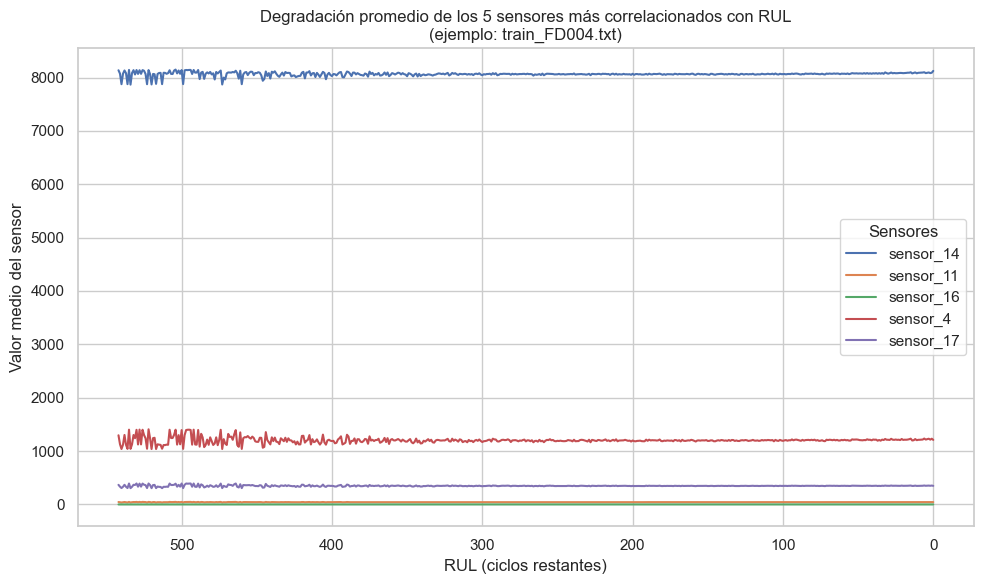

In [8]:
import seaborn as sns

# Selecciona el dataset de ejemplo (train_FD004.txt) ya cargado en df_train_files
df_example = df_train_files['train_FD004.txt'].copy()

# Lista de columnas de sensores (según 'columnas' ya definida en el notebook)
sensores = [f'sensor_{i}' for i in range(1, 22)]

# Asegurar que existan los sensores en el dataframe
sensores = [s for s in sensores if s in df_example.columns]

# Calcular correlación absoluta con RUL y escoger los top N sensores más relevantes
corr_con_rul = df_example[sensores + ['RUL']].corr()['RUL'].abs().drop('RUL')
top_n = 5
sensores_top = corr_con_rul.sort_values(ascending=False).head(top_n).index.tolist()

# Agrupar por RUL y calcular la media (tendencia de degradación)
tendencia = df_example.groupby('RUL')[sensores_top].mean().sort_index()

# Graficar
import matplotlib.pyplot as plt
sns.set(style='whitegrid')

plt.figure(figsize=(10, 6))
for sensor in sensores_top:
    plt.plot(tendencia.index, tendencia[sensor], label=sensor)

plt.xlabel('RUL (ciclos restantes)')
plt.ylabel('Valor medio del sensor')
plt.title(f'Degradación promedio de los {top_n} sensores más correlacionados con RUL\n(ejemplo: train_FD004.txt)')
plt.legend(title='Sensores')
plt.gca().invert_xaxis()  # opcional: mostrar RUL decreciente hacia la derecha
plt.tight_layout()
plt.show()


train_FD001.txt
  Samples: 20631
  RMSE: 41.53
  MAE: 29.70
  R²: 0.6226

train_FD002.txt
  Samples: 53759
  RMSE: 43.39
  MAE: 31.81
  R²: 0.5988

train_FD003.txt
  Samples: 24720
  RMSE: 55.61
  MAE: 37.99
  R²: 0.6845

train_FD004.txt
  Samples: 61249
  RMSE: 55.63
  MAE: 40.12
  R²: 0.6151


C:\Users\Sergio\AppData\Local\Temp\ipykernel_2456\1966164598.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=resultados_df, x='dataset', y='rmse', palette='viridis')


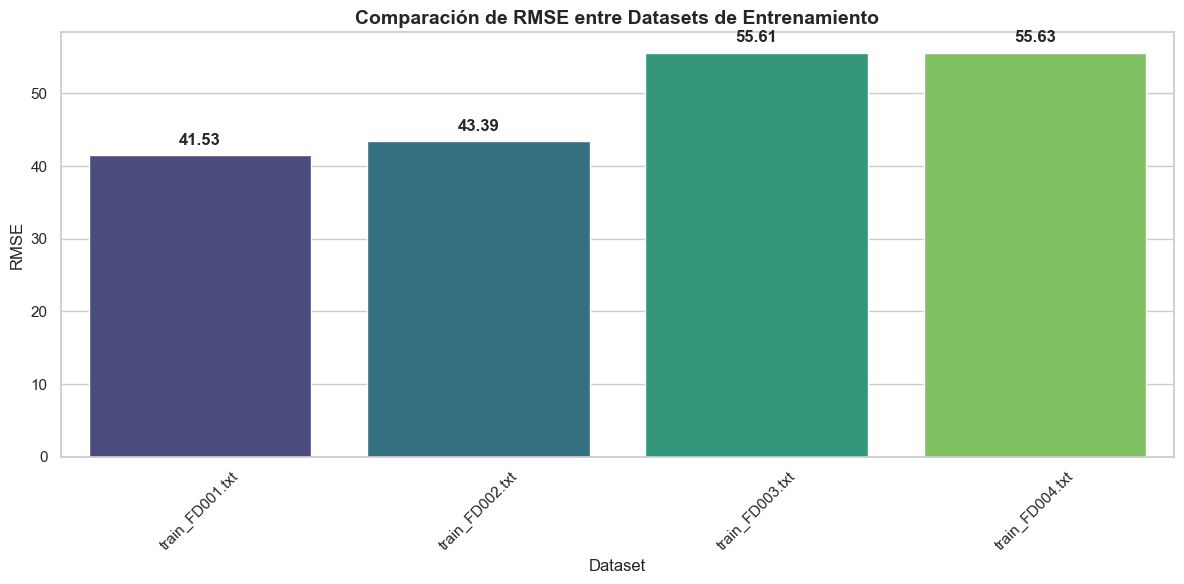

C:\Users\Sergio\AppData\Local\Temp\ipykernel_2456\1966164598.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=resultados_df, x='dataset', y='r2', palette='coolwarm')


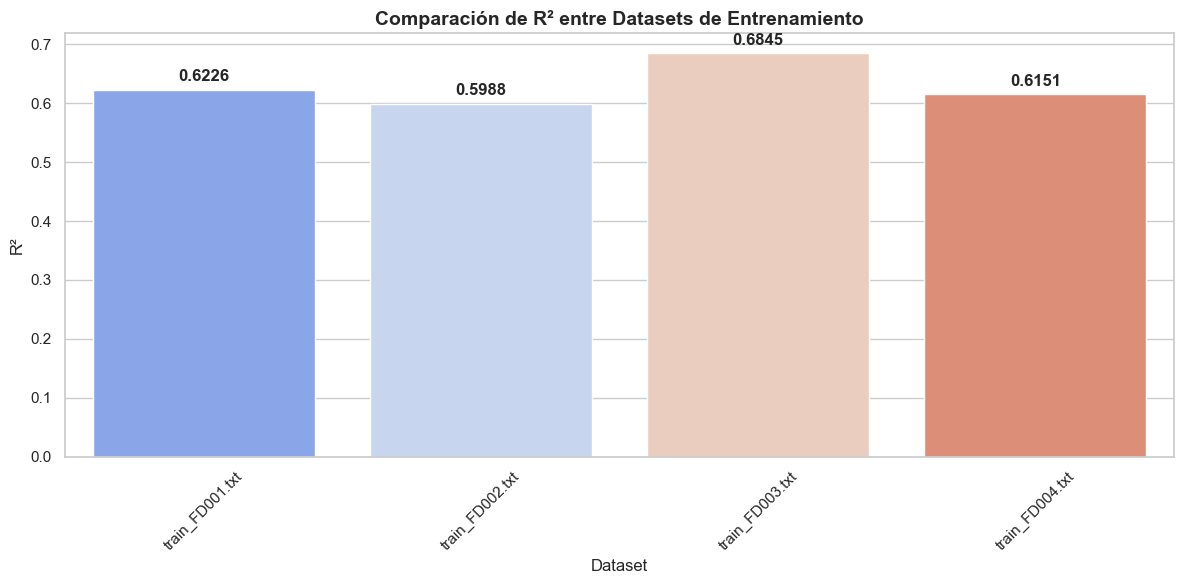

C:\Users\Sergio\AppData\Local\Temp\ipykernel_2456\1966164598.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=resultados_df, x='dataset', y='mae', palette='muted')


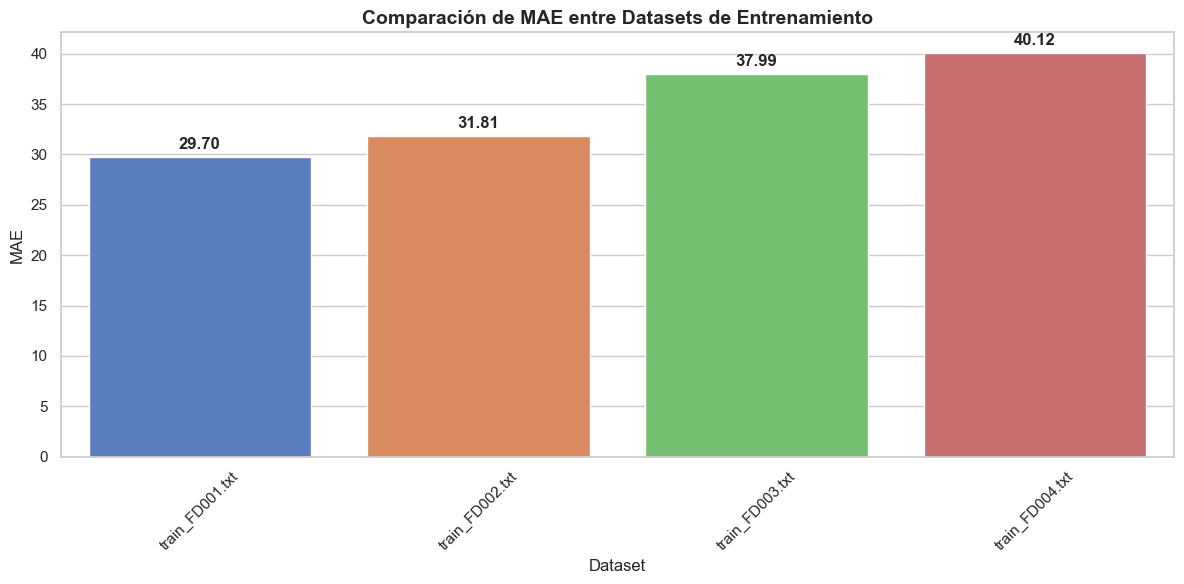

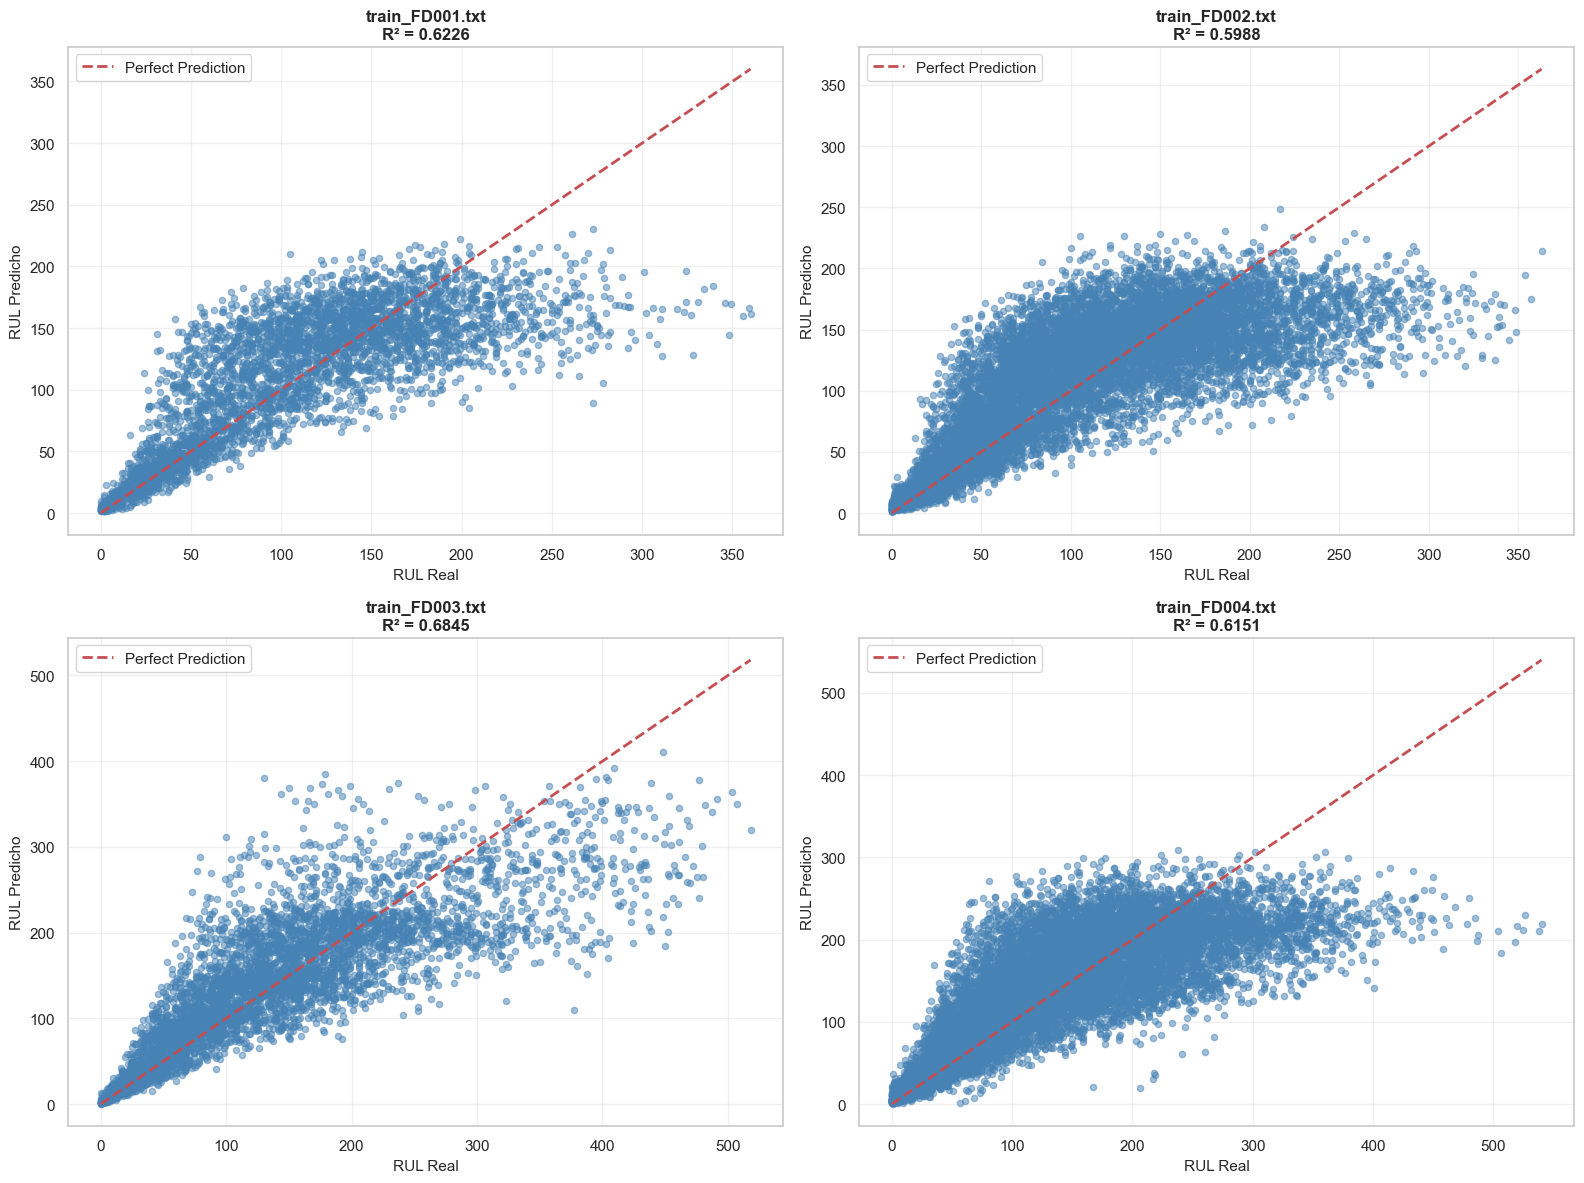

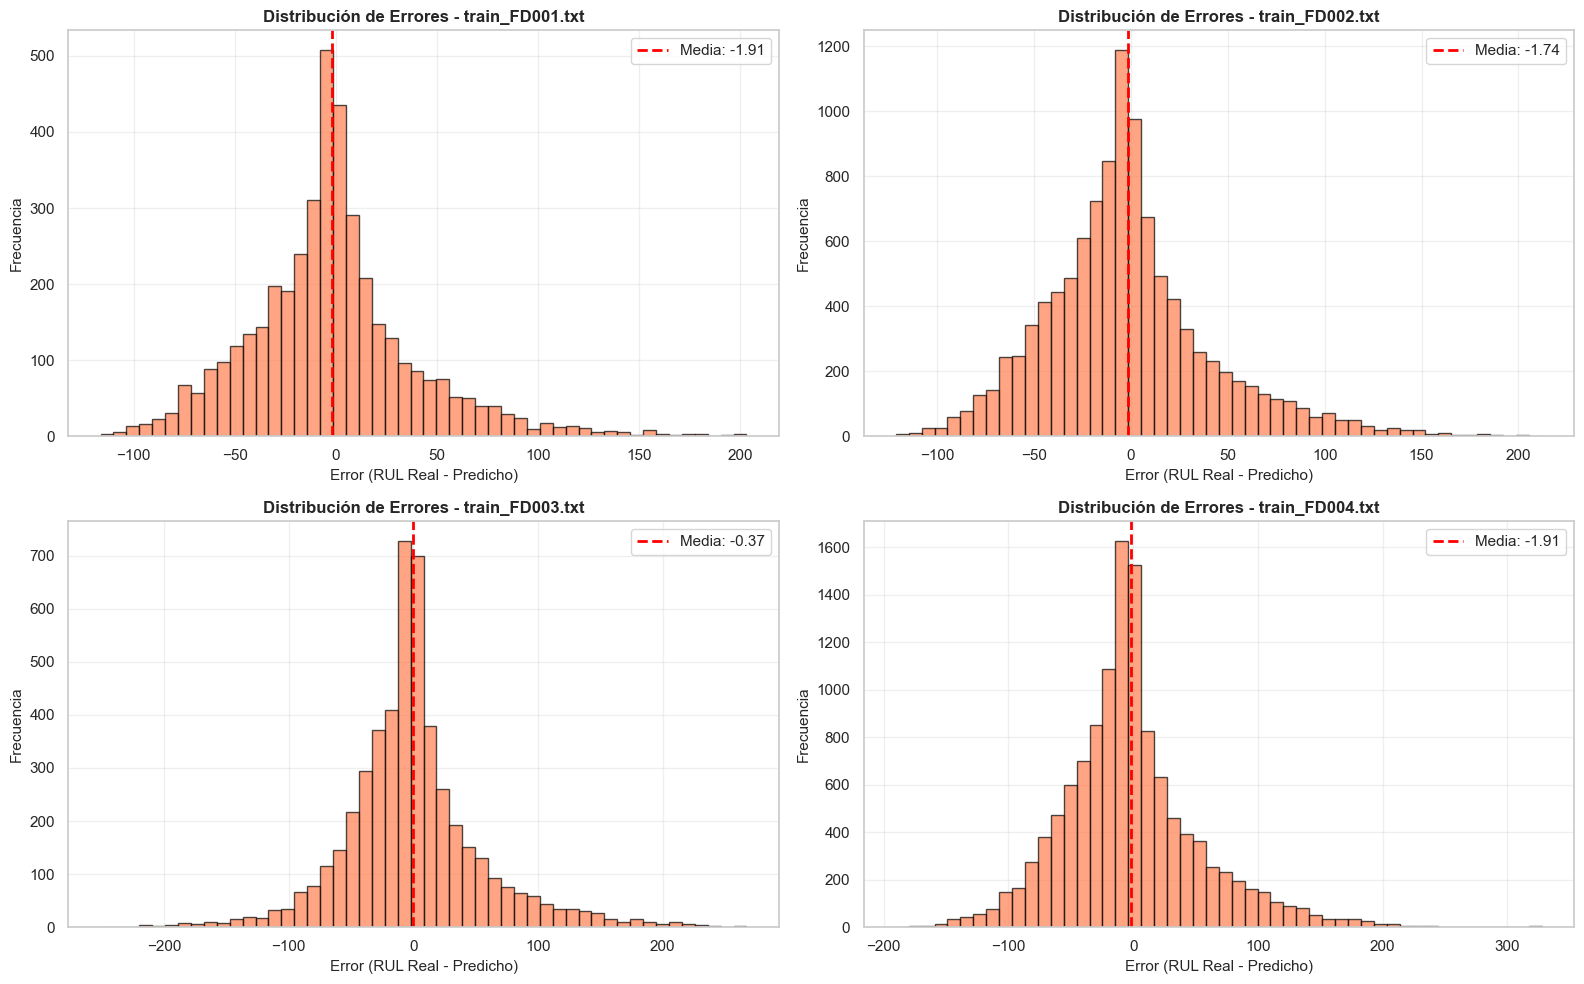


RESUMEN DE RESULTADOS
        dataset      rmse       mae       r2  n_samples
train_FD001.txt 41.525524 29.699760 0.622577      20631
train_FD002.txt 43.390555 31.814338 0.598799      53759
train_FD003.txt 55.607041 37.987433 0.684495      24720
train_FD004.txt 55.632879 40.117238 0.615070      61249


In [17]:
# Entrenar modelos RandomForest para predicción de RUL en todos los datasets
resultados_completos = []
predicciones_comparativas = {}

for nombre, df_temp in df_train_files.items():
    df_temp = df_temp.copy()
    
    # Preparar características y target
    X = df_temp.drop(columns=['motor_id', 'ciclo', 'RUL'])
    y = df_temp['RUL']
    
    # Split train-test
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    
    # Escalar datos
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Entrenar RandomForest
    rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X_train_scaled, y_train)
    y_pred = rf.predict(X_test_scaled)
    
    # Calcular métricas
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = metrics.mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    resultados_completos.append({
        'dataset': nombre,
        'rmse': rmse,
        'mae': mae,
        'r2': r2,
        'n_samples': len(df_temp)
    })
    
    predicciones_comparativas[nombre] = (y_test, y_pred)
    
    print(f"\n{nombre}")
    print(f"  Samples: {len(df_temp)}")
    print(f"  RMSE: {rmse:.2f}")
    print(f"  MAE: {mae:.2f}")
    print(f"  R²: {r2:.4f}")

# Crear DataFrame de resultados
resultados_df = pd.DataFrame(resultados_completos)

# Gráfica 1: Comparación de RMSE entre datasets
plt.figure(figsize=(12, 6))
sns.barplot(data=resultados_df, x='dataset', y='rmse', palette='viridis')
plt.title('Comparación de RMSE entre Datasets de Entrenamiento', fontsize=14, fontweight='bold')
plt.ylabel('RMSE', fontsize=12)
plt.xlabel('Dataset', fontsize=12)
plt.xticks(rotation=45)
for i, v in enumerate(resultados_df['rmse']):
    plt.text(i, v + 1, f'{v:.2f}', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

# Gráfica 2: Comparación de R² entre datasets
plt.figure(figsize=(12, 6))
sns.barplot(data=resultados_df, x='dataset', y='r2', palette='coolwarm')
plt.title('Comparación de R² entre Datasets de Entrenamiento', fontsize=14, fontweight='bold')
plt.ylabel('R²', fontsize=12)
plt.xlabel('Dataset', fontsize=12)
plt.xticks(rotation=45)
for i, v in enumerate(resultados_df['r2']):
    plt.text(i, v + 0.01, f'{v:.4f}', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

# Gráfica 3: Comparación de MAE entre datasets
plt.figure(figsize=(12, 6))
sns.barplot(data=resultados_df, x='dataset', y='mae', palette='muted')
plt.title('Comparación de MAE entre Datasets de Entrenamiento', fontsize=14, fontweight='bold')
plt.ylabel('MAE', fontsize=12)
plt.xlabel('Dataset', fontsize=12)
plt.xticks(rotation=45)
for i, v in enumerate(resultados_df['mae']):
    plt.text(i, v + 0.5, f'{v:.2f}', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

# Gráfica 4: Predicción vs Real para todos los datasets
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, (nombre, (y_test, y_pred)) in enumerate(predicciones_comparativas.items()):
    ax = axes[idx]
    ax.scatter(y_test, y_pred, alpha=0.5, s=20, color='steelblue')
    
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
    
    ax.set_xlabel('RUL Real', fontsize=11)
    ax.set_ylabel('RUL Predicho', fontsize=11)
    ax.set_title(f'{nombre}\nR² = {resultados_df[resultados_df["dataset"]==nombre]["r2"].values[0]:.4f}', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

# Gráfica 5: Distribución de errores por dataset
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for idx, (nombre, (y_test, y_pred)) in enumerate(predicciones_comparativas.items()):
    errors = y_test.values - y_pred
    ax = axes[idx]
    ax.hist(errors, bins=50, edgecolor='black', alpha=0.7, color='coral')
    ax.axvline(errors.mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {errors.mean():.2f}')
    ax.set_xlabel('Error (RUL Real - Predicho)', fontsize=11)
    ax.set_ylabel('Frecuencia', fontsize=11)
    ax.set_title(f'Distribución de Errores - {nombre}', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("RESUMEN DE RESULTADOS")
print("="*80)
print(resultados_df.to_string(index=False))
print("="*80)

train_FD001.txt | LinearRegression -> RMSE: 44.34, MAE: 34.05, R²: 0.5696
train_FD001.txt | RandomForest -> RMSE: 41.53, MAE: 29.70, R²: 0.6226
train_FD002.txt | LinearRegression -> RMSE: 44.92, MAE: 34.72, R²: 0.5700
train_FD002.txt | RandomForest -> RMSE: 43.39, MAE: 31.81, R²: 0.5988
train_FD003.txt | LinearRegression -> RMSE: 62.99, MAE: 46.54, R²: 0.5951
train_FD003.txt | RandomForest -> RMSE: 55.61, MAE: 37.99, R²: 0.6845
train_FD004.txt | LinearRegression -> RMSE: 60.28, MAE: 46.13, R²: 0.5481
train_FD004.txt | RandomForest -> RMSE: 55.63, MAE: 40.12, R²: 0.6151


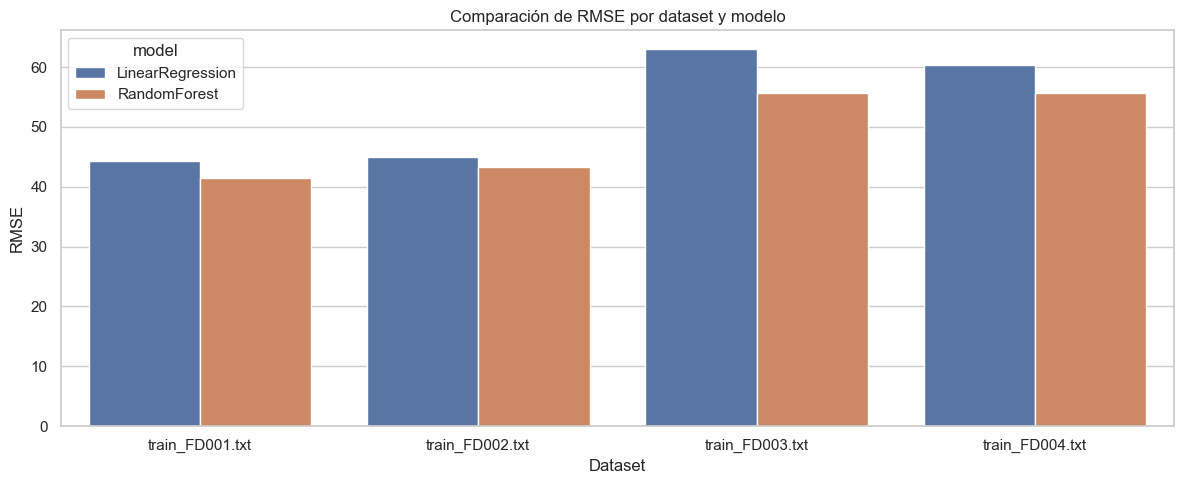

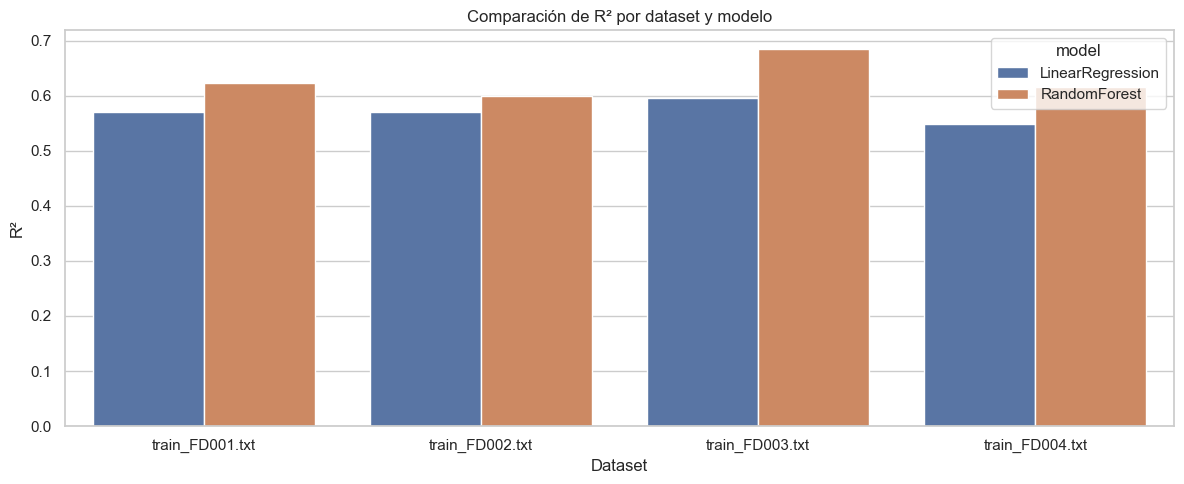

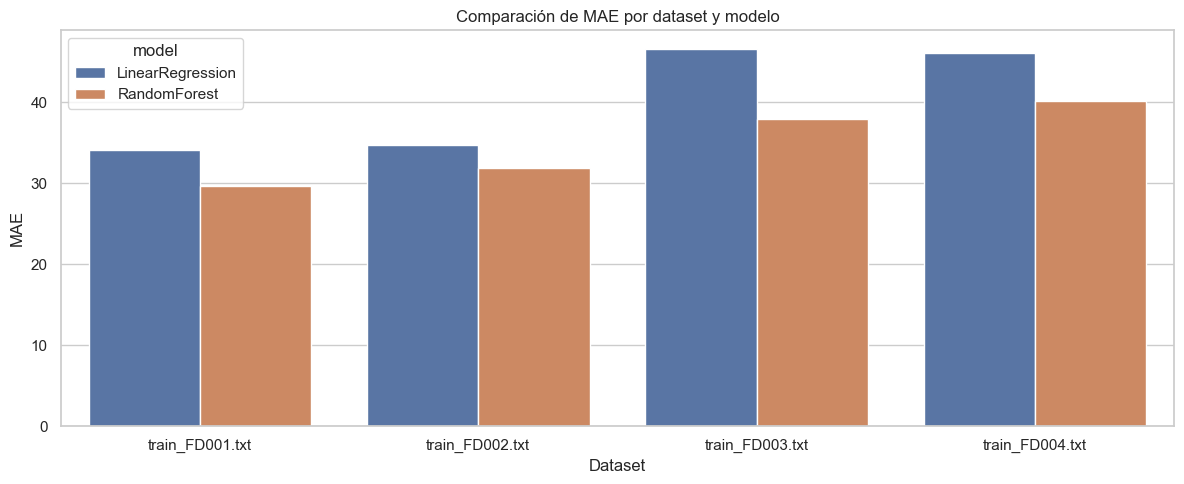

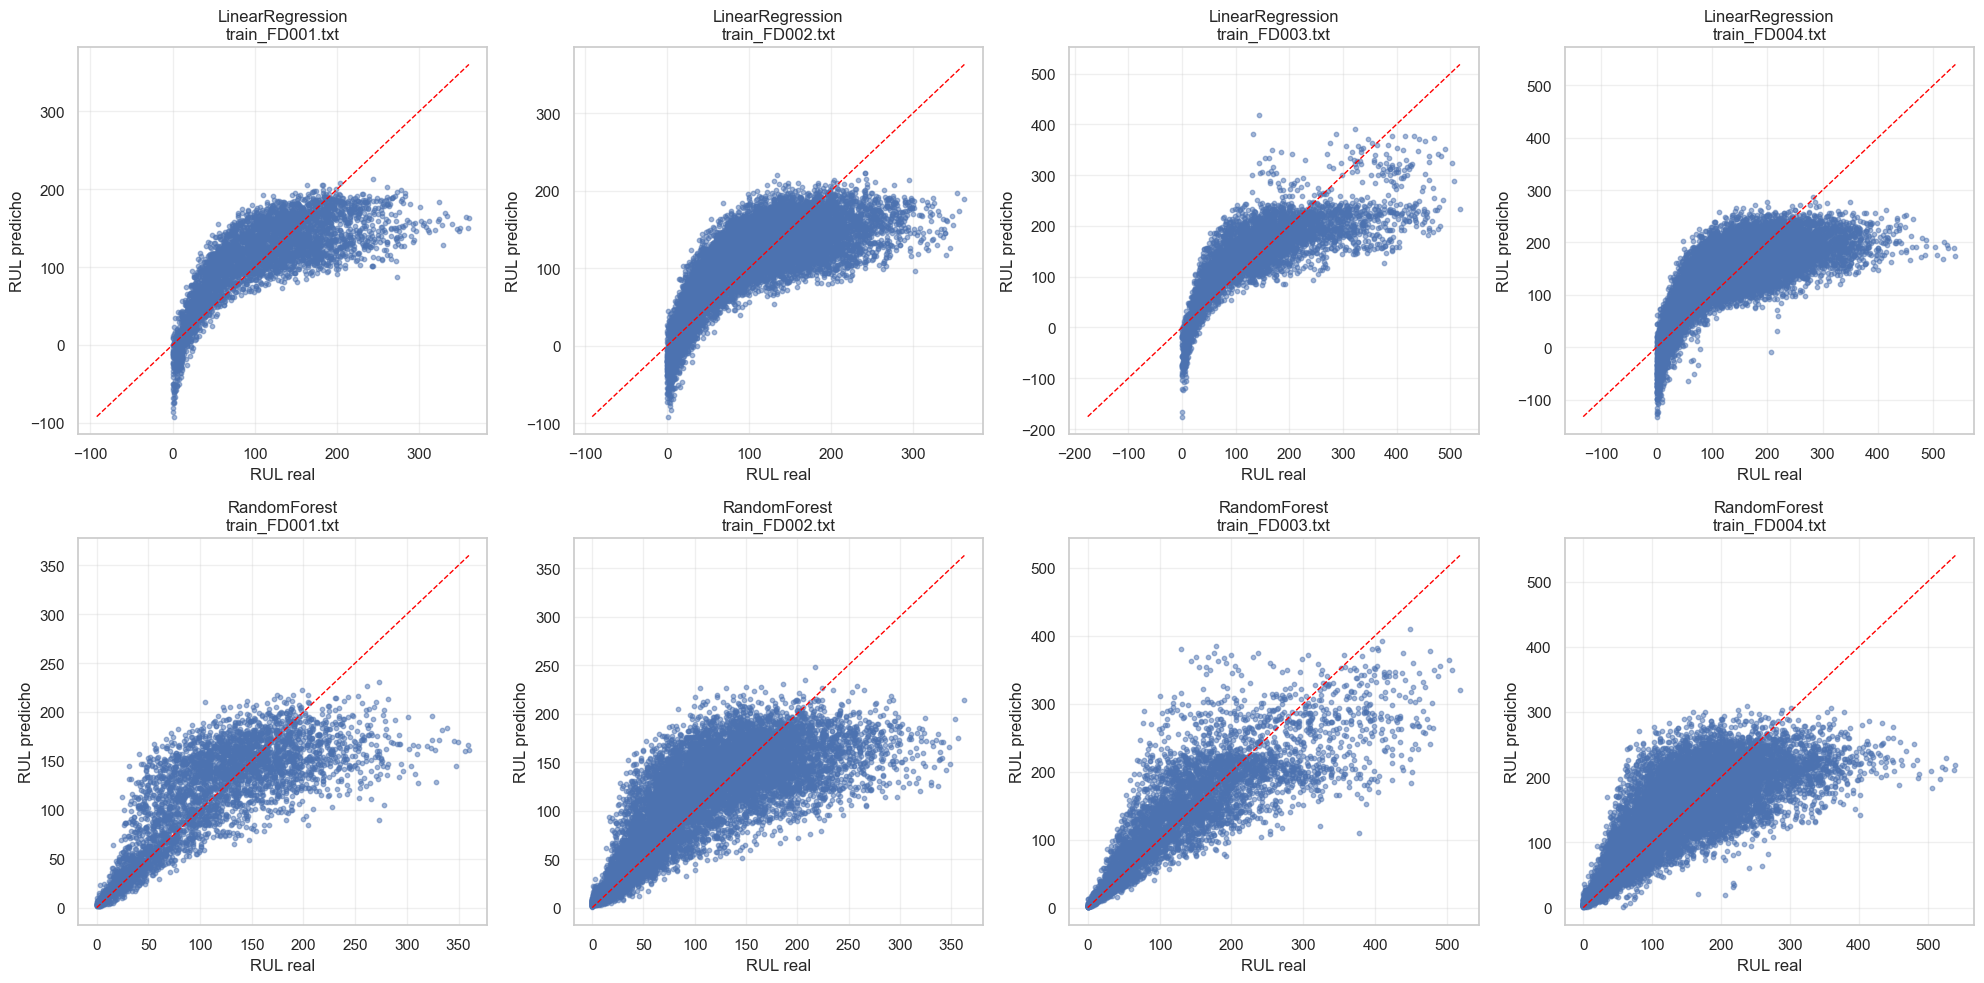

           dataset             model       rmse        mae        r2
0  train_FD001.txt  LinearRegression  44.341868  34.050297  0.569646
1  train_FD001.txt      RandomForest  41.525524  29.699760  0.622577
2  train_FD002.txt  LinearRegression  44.919121  34.716162  0.570034
3  train_FD002.txt      RandomForest  43.390555  31.814338  0.598799
4  train_FD003.txt  LinearRegression  62.993373  46.539415  0.595111
5  train_FD003.txt      RandomForest  55.607041  37.987433  0.684495
6  train_FD004.txt  LinearRegression  60.281613  46.134592  0.548051
7  train_FD004.txt      RandomForest  55.632879  40.117238  0.615070


In [18]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt

resultados_modelos = []
predicciones_modelos = {}

for nombre, df_temp in df_train_files.items():
    df_temp = df_temp.copy()

    X = df_temp.drop(columns=['motor_id', 'ciclo', 'RUL'])
    y = df_temp['RUL']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    modelos = {
        'LinearRegression': LinearRegression(),
        'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    }

    for modelo_nombre, modelo in modelos.items():
        modelo.fit(X_train_scaled, y_train)
        y_pred = modelo.predict(X_test_scaled)

        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        resultados_modelos.append({
            'dataset': nombre,
            'model': modelo_nombre,
            'rmse': rmse,
            'mae': mae,
            'r2': r2
        })

        predicciones_modelos[(nombre, modelo_nombre)] = (y_test, y_pred)

        print(f"{nombre} | {modelo_nombre} -> RMSE: {rmse:.2f}, MAE: {mae:.2f}, R²: {r2:.4f}")

resultados_df = pd.DataFrame(resultados_modelos)

plt.figure(figsize=(12, 5))
sns.barplot(
    data=resultados_df,
    x='dataset',
    y='rmse',
    hue='model',
    order=sorted(df_train_files.keys())
)
plt.title('Comparación de RMSE por dataset y modelo')
plt.xlabel('Dataset')
plt.ylabel('RMSE')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
sns.barplot(
    data=resultados_df,
    x='dataset',
    y='r2',
    hue='model',
    order=sorted(df_train_files.keys())
)
plt.title('Comparación de R² por dataset y modelo')
plt.xlabel('Dataset')
plt.ylabel('R²')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
sns.barplot(
    data=resultados_df,
    x='dataset',
    y='mae',
    hue='model',
    order=sorted(df_train_files.keys())
)
plt.title('Comparación de MAE por dataset y modelo')
plt.xlabel('Dataset')
plt.ylabel('MAE')
plt.tight_layout()
plt.show()

datasets_ordenados = sorted(df_train_files.keys())
fig, axes = plt.subplots(2, len(datasets_ordenados), figsize=(20, 10), sharex=False, sharey=False)

for col, nombre in enumerate(datasets_ordenados):
    for row, modelo_nombre in enumerate(['LinearRegression', 'RandomForest']):
        y_test, y_pred = predicciones_modelos[(nombre, modelo_nombre)]
        ax = axes[row, col]
        ax.scatter(y_test, y_pred, s=10, alpha=0.5)
        min_val = min(y_test.min(), y_pred.min())
        max_val = max(y_test.max(), y_pred.max())
        ax.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=1)
        ax.set_title(f'{modelo_nombre}\n{nombre}')
        ax.set_xlabel('RUL real')
        ax.set_ylabel('RUL predicho')
        ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(resultados_df)

In [3]:
ruta_destino = './datos_turbina'
if not os.path.isdir(ruta_destino):
    raise FileNotFoundError(f"No existe la carpeta de destino: {ruta_destino}")

archivos = sorted([
    f for f in os.listdir(ruta_destino)
    if os.path.isfile(os.path.join(ruta_destino, f))
])

print(f"Archivos encontrados en '{ruta_destino}':")
for nombre in archivos:
    print(" -", nombre)

dataframes_turbina = {}

ruta_csv = os.path.join(ruta_destino, 'gas_turbine_fault_detection.csv')
if os.path.exists(ruta_csv):
    df_gas = pd.read_csv(ruta_csv)
    dataframes_turbina['gas_turbine_fault_detection.csv'] = df_gas
    print(f"\nDataset integrado desde: {ruta_csv}")

    sensores = [col for col in df_gas.columns if 'sensor' in col.lower()]
    if sensores:
        print("\nPrimeros 5 valores de cada sensor:")
        for sensor in sensores:
            valores = df_gas[sensor].head(5).tolist()
            print(f" - {sensor}: {valores}")
    else:
        print("\nNo se encontraron columnas de sensor en el dataset.")
else:
    print(f"\nNo se encontró el archivo de dataset esperado: {ruta_csv}")

for nombre in archivos:
    ruta = os.path.join(ruta_destino, nombre)
    ext = os.path.splitext(nombre)[1].lower()

    try:
        if ext == '.csv':
            df = pd.read_csv(ruta)
        elif ext == '.txt':
            df = pd.read_csv(ruta, sep='\s+', header=None)
        elif ext == '.json':
            df = pd.read_json(ruta)
        elif ext in ('.parquet', '.pq'):
            df = pd.read_parquet(ruta)
        else:
            continue

        dataframes_turbina[nombre] = df
        print(f"\nCargado '{nombre}' con shape {df.shape}:")
        print(df.head(5))

    except Exception as e:
        print(f"\nNo se pudo cargar '{nombre}': {e}")

if not dataframes_turbina:
    print("\nNo se encontró ningún dataset compatible en la carpeta.")

print(f"Archivos encontrados en '{ruta_destino}':")
for nombre in archivos:
    print(" -", nombre)

dataframes_turbina = {}

ruta_csv = os.path.join(ruta_destino, 'gas_turbine_fault_detection.csv')
if os.path.exists(ruta_csv):
    df_gas = pd.read_csv(ruta_csv)
    dataframes_turbina['gas_turbine_fault_detection.csv'] = df_gas
    print(f"\nDataset integrado desde: {ruta_csv}")

    sensores = [col for col in df_gas.columns if 'sensor' in col.lower()]
    if sensores:
        print("\nPrimeros 5 valores de cada sensor:")
        for sensor in sensores:
            valores = df_gas[sensor].head(5).tolist()
            print(f" - {sensor}: {valores}")
    else:
        print("\nNo se encontraron columnas de sensor en el dataset.")
else:
    print(f"\nNo se encontró el archivo de dataset esperado: {ruta_csv}")

for nombre in archivos:
    ruta = os.path.join(ruta_destino, nombre)
    ext = os.path.splitext(nombre)[1].lower()

    try:
        if ext == '.csv':
            df = pd.read_csv(ruta)
        elif ext == '.txt':
            df = pd.read_csv(ruta, sep='\s+', header=None)
        elif ext == '.json':
            df = pd.read_json(ruta)
        elif ext in ('.parquet', '.pq'):
            df = pd.read_parquet(ruta)
        else:
            continue

        dataframes_turbina[nombre] = df
        print(f"\nCargado '{nombre}' con shape {df.shape}:")
        print(df.head(5))

    except Exception as e:
        print(f"\nNo se pudo cargar '{nombre}': {e}")

if not dataframes_turbina:
    print("\nNo se encontró ningún dataset compatible en la carpeta.")

Archivos encontrados en './datos_turbina':
 - gas_turbine_fault_detection.csv

Dataset integrado desde: ./datos_turbina\gas_turbine_fault_detection.csv

No se encontraron columnas de sensor en el dataset.

Cargado 'gas_turbine_fault_detection.csv' con shape (1386, 10):
   Temperature (°C)           RPM  Torque (Nm)  Vibrations (mm/s)  \
0        924.835708  15650.870645  3464.645167           1.675087   
1        893.086785  15780.755598  3190.276340           2.042084   
2        932.384427  15016.002075  3401.769251           2.006414   
3        976.151493  14623.291065  3443.024901           2.239914   
4        888.292331  15229.986071  3448.764050           1.865677   

   Power Output (MW)  Fuel Flow Rate (kg/s)  Air Pressure (kPa)  \
0          96.347590               2.265294          146.245460   
1          83.288302               2.755950          166.812134   
2         120.358735               2.574244          133.494161   
3         104.689781               2.497101    

In [7]:
def calcular_rul_fault(df, fault_col='Fault'):
    df = df.copy()
    if fault_col not in df.columns:
        return df

    distancia = float('inf')
    rul = pd.Series(index=df.index, dtype='float64')

    for idx in reversed(df.index):
        if df.at[idx, fault_col] == 1:
            distancia = 0
        elif distancia != float('inf'):
            distancia += 1
        rul.at[idx] = distancia if distancia != float('inf') else pd.NA

    df['RUL'] = rul
    return df

for nombre, df_temp in dataframes_turbina.items():
    if 'Fault' not in df_temp.columns:
        continue

    df_temp = limpiar_dataframe(df_temp)
    df_temp = calcular_rul_fault(df_temp)

    dataframes_turbina[nombre] = df_temp
    if nombre == 'gas_turbine_fault_detection.csv':
        df_gas = df_temp

    print(f"\nDataset: {nombre}")
    print("Shape final:", df_temp.shape)
    print("Valores únicos de Fault:", df_temp['Fault'].unique())
    print(df_temp[['Fault', 'RUL']].head(10))


Dataset: gas_turbine_fault_detection.csv
Shape final: (1386, 11)
Valores únicos de Fault: [0 1]
   Fault  RUL
0      0  3.0
1      0  2.0
2      0  1.0
3      1  0.0
4      1  0.0
5      0  7.0
6      0  6.0
7      0  5.0
8      0  4.0
9      0  3.0


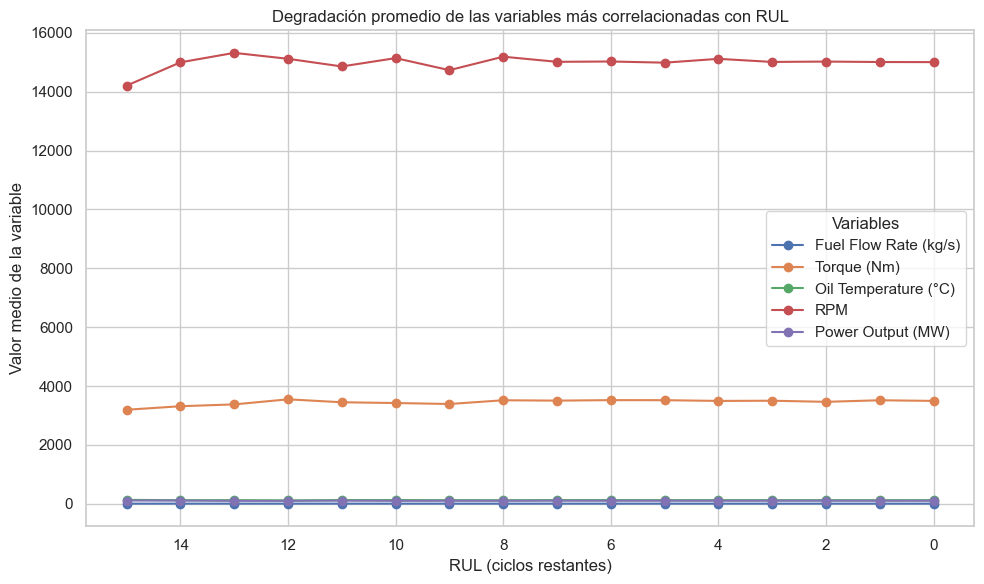

Variables más relevantes: ['Fuel Flow Rate (kg/s)', 'Torque (Nm)', 'Oil Temperature (°C)', 'RPM', 'Power Output (MW)']
Fuel Flow Rate (kg/s)    0.042717
Torque (Nm)              0.029621
Oil Temperature (°C)     0.028483
RPM                      0.020193
Power Output (MW)        0.020013
Name: RUL, dtype: float64


In [9]:
# Seleccionar las columnas del dataset de turbina que representan mediciones tipo sensor
columnas_gas = [col for col in df_gas.columns if col not in ['Fault', 'RUL']]

# Calcular la correlación absoluta con RUL para escoger las variables más relevantes
corr_gas = df_gas[columnas_gas + ['RUL']].corr()['RUL'].abs().drop('RUL')
top_n = 5
sensores_relevantes = corr_gas.sort_values(ascending=False).head(top_n).index.tolist()

# Agrupar por RUL y calcular la media de los sensores seleccionados para mostrar la degradación
tendencia_gas = df_gas.groupby('RUL')[sensores_relevantes].mean().sort_index()

plt.figure(figsize=(10, 6))
for sensor in sensores_relevantes:
    plt.plot(tendencia_gas.index, tendencia_gas[sensor], marker='o', label=sensor)

plt.xlabel('RUL (ciclos restantes)')
plt.ylabel('Valor medio de la variable')
plt.title('Degradación promedio de las variables más correlacionadas con RUL')
plt.legend(title='Variables')
plt.gca().invert_xaxis()
plt.tight_layout()
plt.show()

print("Variables más relevantes:", sensores_relevantes)
print(corr_gas.sort_values(ascending=False).head(top_n))

LinearRegression -> RMSE: 2.62, MAE: 1.93, R²: -0.0067
RandomForest -> RMSE: 2.75, MAE: 2.06, R²: -0.1162


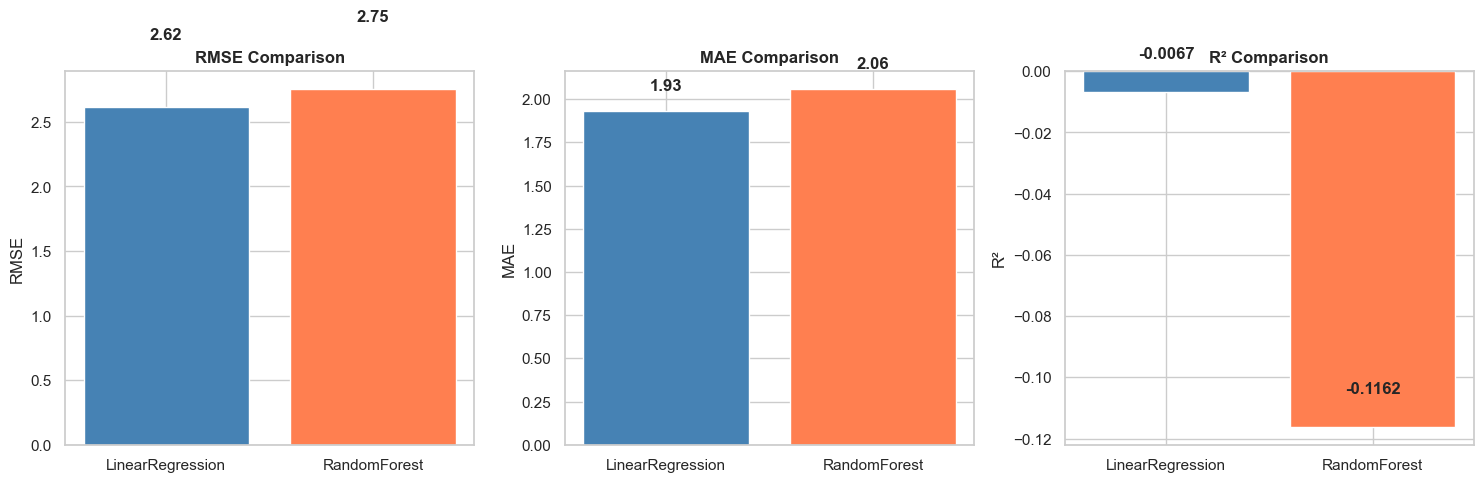

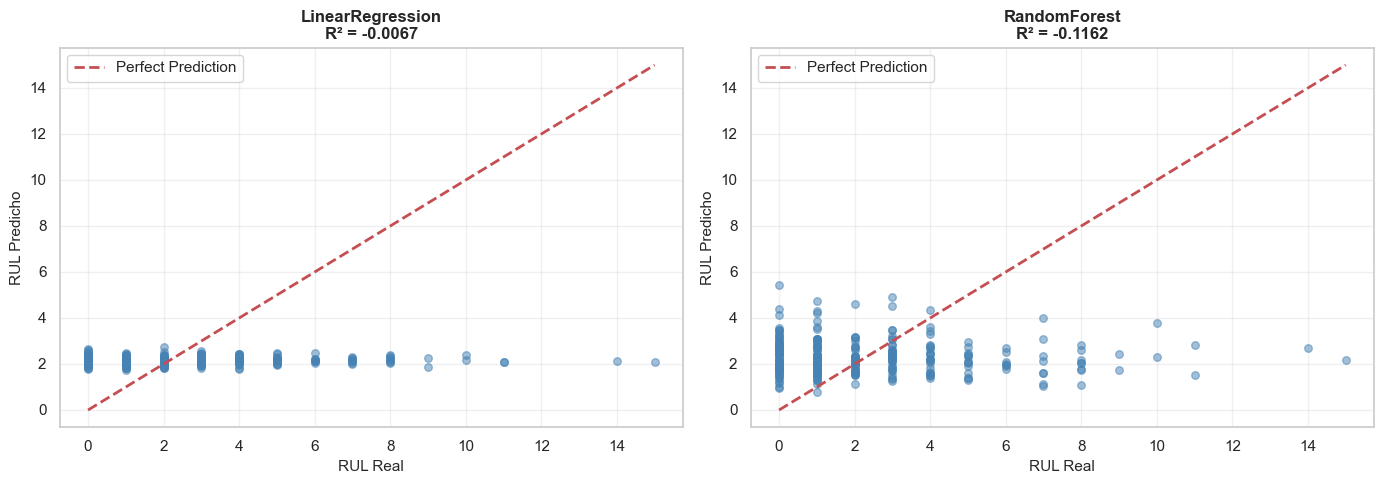

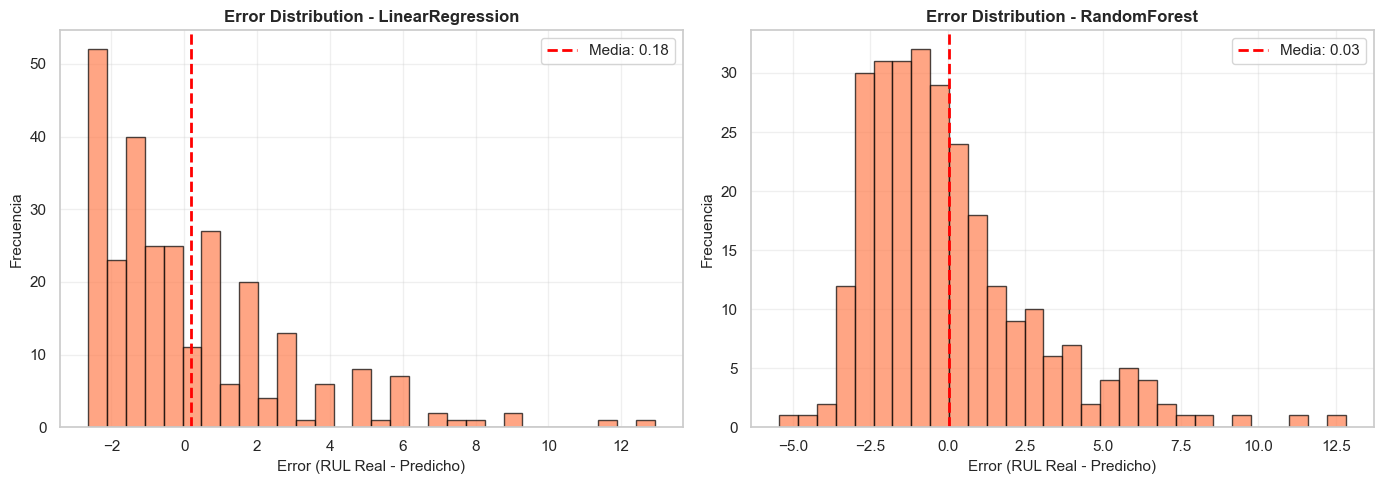


RESULTS SUMMARY - Gas Turbine Dataset
           model     rmse      mae        r2
LinearRegression 2.616013 1.932173 -0.006704
    RandomForest 2.754647 2.058375 -0.116231


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Train LinearRegression and RandomForest models on gas turbine dataset
import matplotlib.pyplot as plt

# Prepare data from gas turbine dataset
df_gas_clean = df_gas.dropna(subset=['RUL']).copy()

X = df_gas_clean[columnas_gas]
y = df_gas_clean['RUL']

# Split train-test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train both models
resultados_gas = []
predicciones_gas = {}

modelos_gas = {
    'LinearRegression': LinearRegression(),
    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
}

for modelo_nombre, modelo in modelos_gas.items():
    modelo.fit(X_train_scaled, y_train)
    y_pred = modelo.predict(X_test_scaled)
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    resultados_gas.append({
        'model': modelo_nombre,
        'rmse': rmse,
        'mae': mae,
        'r2': r2
    })
    
    predicciones_gas[modelo_nombre] = (y_test, y_pred)
    
    print(f"{modelo_nombre} -> RMSE: {rmse:.2f}, MAE: {mae:.2f}, R²: {r2:.4f}")

resultados_gas_df = pd.DataFrame(resultados_gas)

# Plot 1: RMSE Comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].bar(resultados_gas_df['model'], resultados_gas_df['rmse'], color=['steelblue', 'coral'])
axes[0].set_title('RMSE Comparison', fontweight='bold')
axes[0].set_ylabel('RMSE')
for i, v in enumerate(resultados_gas_df['rmse']):
    axes[0].text(i, v + 0.5, f'{v:.2f}', ha='center', va='bottom', fontweight='bold')

# Plot 2: MAE Comparison
axes[1].bar(resultados_gas_df['model'], resultados_gas_df['mae'], color=['steelblue', 'coral'])
axes[1].set_title('MAE Comparison', fontweight='bold')
axes[1].set_ylabel('MAE')
for i, v in enumerate(resultados_gas_df['mae']):
    axes[1].text(i, v + 0.1, f'{v:.2f}', ha='center', va='bottom', fontweight='bold')

# Plot 3: R² Comparison
axes[2].bar(resultados_gas_df['model'], resultados_gas_df['r2'], color=['steelblue', 'coral'])
axes[2].set_title('R² Comparison', fontweight='bold')
axes[2].set_ylabel('R²')
for i, v in enumerate(resultados_gas_df['r2']):
    axes[2].text(i, v + 0.01, f'{v:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Plot 4: Predictions vs Real for both models
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, (modelo_nombre, (y_test_vals, y_pred_vals)) in enumerate(predicciones_gas.items()):
    ax = axes[idx]
    ax.scatter(y_test_vals, y_pred_vals, alpha=0.5, s=30, color='steelblue')
    
    min_val = min(y_test_vals.min(), y_pred_vals.min())
    max_val = max(y_test_vals.max(), y_pred_vals.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
    
    ax.set_xlabel('RUL Real', fontsize=11)
    ax.set_ylabel('RUL Predicho', fontsize=11)
    ax.set_title(f'{modelo_nombre}\nR² = {resultados_gas_df[resultados_gas_df["model"]==modelo_nombre]["r2"].values[0]:.4f}', fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

# Plot 5: Error Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, (modelo_nombre, (y_test_vals, y_pred_vals)) in enumerate(predicciones_gas.items()):
    errors = y_test_vals.values - y_pred_vals
    ax = axes[idx]
    ax.hist(errors, bins=30, edgecolor='black', alpha=0.7, color='coral')
    ax.axvline(errors.mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {errors.mean():.2f}')
    ax.set_xlabel('Error (RUL Real - Predicho)', fontsize=11)
    ax.set_ylabel('Frecuencia', fontsize=11)
    ax.set_title(f'Error Distribution - {modelo_nombre}', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("RESULTS SUMMARY - Gas Turbine Dataset")
print("="*60)
print(resultados_gas_df.to_string(index=False))

LinearRegression -> RMSE: 2.1806, MAE: 1.5160, R²: 0.3005
RandomForest    -> RMSE: 2.1223, MAE: 1.3636, R²: 0.3374
GradientBoosting -> RMSE: 2.2158, MAE: 1.5024, R²: 0.2777


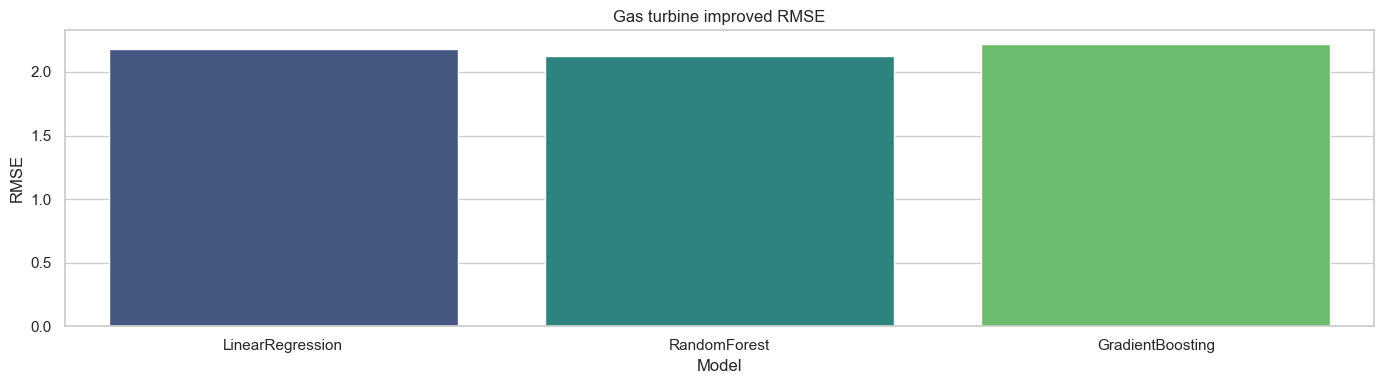

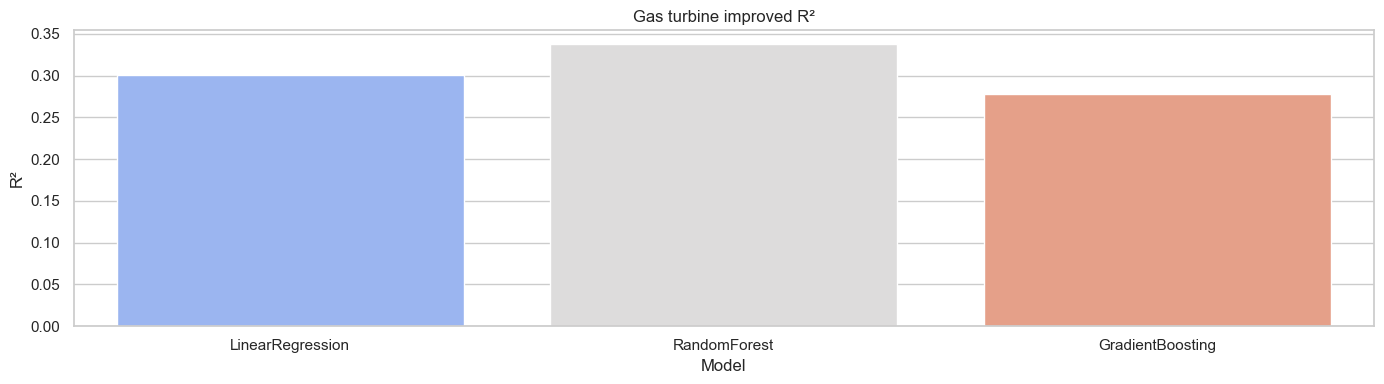

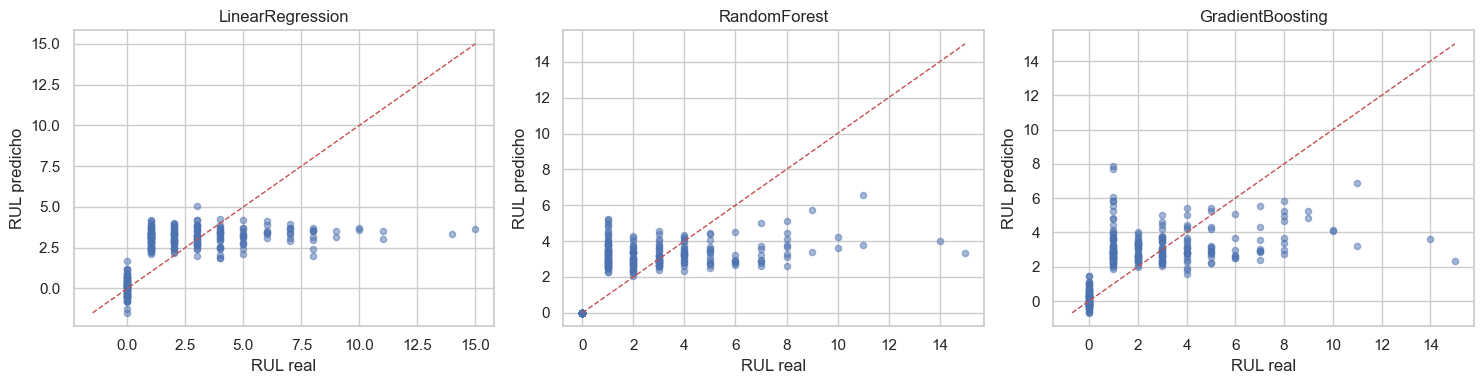


Top 12 features from RandomForest:
Fault                                0.362984
Torque (Nm)_roll_mean_5              0.036492
Temperature (°C)_roll_mean_5         0.036064
Vibrations (mm/s)                    0.034258
Torque (Nm)_roll_std_5               0.026047
Power Output (MW)_roll_mean_5        0.025489
Fuel Flow Rate (kg/s)_roll_mean_5    0.023959
Exhaust Gas Temperature (°C)         0.023404
Oil Temperature (°C)_roll_std_5      0.022118
Temperature (°C)_roll_std_5          0.019758
Oil Temperature (°C)_roll_mean_5     0.019363
Fuel Flow Rate (kg/s)_roll_std_5     0.019300
dtype: float64


In [23]:
from sklearn.preprocessing import RobustScaler, PolynomialFeatures
from sklearn.ensemble import GradientBoostingRegressor

df_gas_improved = df_gas.dropna(subset=['RUL']).copy()
df_gas_improved.drop_duplicates(inplace=True)
df_gas_improved.reset_index(drop=True, inplace=True)

for col in df_gas_improved.columns:
    if df_gas_improved[col].isna().any():
        if pd.api.types.is_numeric_dtype(df_gas_improved[col]):
            df_gas_improved[col].fillna(df_gas_improved[col].median(), inplace=True)
        else:
            df_gas_improved[col].fillna(
                df_gas_improved[col].mode().iloc[0] if not df_gas_improved[col].mode().empty else '',
                inplace=True
            )

numeric_cols = df_gas_improved.select_dtypes(include='number').columns.tolist()
constant_cols = [c for c in numeric_cols if df_gas_improved[c].nunique() <= 1 and c != 'RUL']
if constant_cols:
    df_gas_improved.drop(columns=constant_cols, inplace=True)

corr_rul = df_gas_improved[numeric_cols].corr()['RUL'].abs().sort_values(ascending=False)
top_features = [c for c in corr_rul.index if c != 'RUL'][:7]

window = 5
for col in top_features:
    df_gas_improved[f'{col}_diff'] = df_gas_improved[col].diff().fillna(0)
    df_gas_improved[f'{col}_roll_mean_{window}'] = df_gas_improved[col].rolling(window, min_periods=1).mean()
    df_gas_improved[f'{col}_roll_std_{window}'] = df_gas_improved[col].rolling(window, min_periods=1).std().fillna(0)

poly_features = [f for f in top_features if f != 'Fault'][:5]
poly = PolynomialFeatures(degree=2, include_bias=False)
poly_arr = poly.fit_transform(df_gas_improved[poly_features])
poly_cols = poly.get_feature_names_out(poly_features)
df_poly = pd.DataFrame(poly_arr, columns=poly_cols, index=df_gas_improved.index)
df_gas_improved = pd.concat([df_gas_improved, df_poly], axis=1)

feature_cols = [col for col in df_gas_improved.select_dtypes(include='number').columns if col != 'RUL']

X = df_gas_improved[feature_cols]
y = df_gas_improved['RUL']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

modelos = {
    'LinearRegression': LinearRegression(),
    'RandomForest': RandomForestRegressor(n_estimators=250, max_depth=15, random_state=42, n_jobs=-1),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=200, max_depth=4, random_state=42)
}

resultados_gas_improved = []
predicciones_gas_improved = {}

for modelo_nombre, modelo in modelos.items():
    modelo.fit(X_train_scaled, y_train)
    y_pred = modelo.predict(X_test_scaled)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    resultados_gas_improved.append({
        'model': modelo_nombre,
        'rmse': rmse,
        'mae': mae,
        'r2': r2
    })
    predicciones_gas_improved[modelo_nombre] = (y_test, y_pred)

    print(f"{modelo_nombre:15s} -> RMSE: {rmse:.4f}, MAE: {mae:.4f}, R²: {r2:.4f}")

resultados_gas_improved_df = pd.DataFrame(resultados_gas_improved)

plt.figure(figsize=(14, 4))
sns.barplot(data=resultados_gas_improved_df, x='model', y='rmse', palette='viridis')
plt.title('Gas turbine improved RMSE')
plt.ylabel('RMSE')
plt.xlabel('Model')
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 4))
sns.barplot(data=resultados_gas_improved_df, x='model', y='r2', palette='coolwarm')
plt.title('Gas turbine improved R²')
plt.ylabel('R²')
plt.xlabel('Model')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, len(predicciones_gas_improved), figsize=(15, 4))
for ax, (modelo_nombre, (y_test_vals, y_pred_vals)) in zip(axes, predicciones_gas_improved.items()):
    ax.scatter(y_test_vals, y_pred_vals, alpha=0.5, s=20)
    min_val = min(y_test_vals.min(), y_pred_vals.min())
    max_val = max(y_test_vals.max(), y_pred_vals.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1)
    ax.set_title(modelo_nombre)
    ax.set_xlabel('RUL real')
    ax.set_ylabel('RUL predicho')

plt.tight_layout()
plt.show()

if 'RandomForest' in modelos:
    rf_model = modelos['RandomForest']
    if hasattr(rf_model, 'feature_importances_'):
        cols = X_train.columns if isinstance(X_train, pd.DataFrame) else feature_cols
        fi_vals = rf_model.feature_importances_
        if len(fi_vals) != len(cols):
            n = min(len(fi_vals), len(cols))
            fi = pd.Series(fi_vals[:n], index=list(cols)[:n]).sort_values(ascending=False).head(12)
        else:
            fi = pd.Series(fi_vals, index=cols).sort_values(ascending=False).head(12)
        print("\nTop 12 features from RandomForest:")
        print(fi)

In [13]:
import os
import numpy as np
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures

# Normalizar la ruta del CSV (compatibilidad con Windows/Linux)
ruta_input = ruta_csv.replace("\\", os.sep).replace("/", os.sep)
ruta_input = os.path.normpath(ruta_input)

# Obtener el DataFrame base (usar el ya cargado en el notebook si existe)
if 'df_gas' in globals():
    df_base = df_gas.copy()
elif 'dataframes_turbina' in globals() and 'gas_turbine_fault_detection.csv' in dataframes_turbina:
    df_base = dataframes_turbina['gas_turbine_fault_detection.csv'].copy()
else:
    df_base = pd.read_csv(ruta_input)

# 1) Preparar dataframe limpio para augmentation
df_aug = df_base.dropna(subset=['RUL']).copy()
df_aug = df_aug.drop_duplicates().reset_index(drop=True)

# 2) Limpieza básica de NaN
for col in df_aug.columns:
    if df_aug[col].isna().any():
        if pd.api.types.is_numeric_dtype(df_aug[col]):
            df_aug[col] = df_aug[col].fillna(df_aug[col].median())
        else:
            mode_val = df_aug[col].mode(dropna=True)
            df_aug[col] = df_aug[col].fillna(mode_val.iloc[0] if not mode_val.empty else "")

# 3) Eliminar columnas constantes
numeric_cols = df_aug.select_dtypes(include='number').columns.tolist()
constant_cols = [c for c in numeric_cols if df_aug[c].nunique() <= 1]
df_aug = df_aug.drop(columns=constant_cols)

# 4) Seleccionar features con mayor relación con RUL
corr_rul = df_aug.select_dtypes(include='number').corr()['RUL'].abs().sort_values(ascending=False)
top_features = [c for c in corr_rul.index if c not in ['RUL', 'Fault']][:8]

# 5) Crear features temporales y de tendencia
for col in top_features:
    df_aug[f'{col}_diff1'] = df_aug[col].diff().fillna(0)
    df_aug[f'{col}_lag1'] = df_aug[col].shift(1).fillna(df_aug[col].mean())
    df_aug[f'{col}_roll_mean_3'] = df_aug[col].rolling(3, min_periods=1).mean()
    df_aug[f'{col}_roll_std_3'] = df_aug[col].rolling(3, min_periods=1).std().fillna(0)

# 6) Crear interacciones entre features top
if len(top_features) >= 2:
    poly = PolynomialFeatures(degree=2, include_bias=False, interaction_only=True)
    poly_df = pd.DataFrame(
        poly.fit_transform(df_aug[top_features]),
        columns=poly.get_feature_names_out(top_features),
        index=df_aug.index
    )
    df_aug = pd.concat([df_aug, poly_df], axis=1)

# 7) Crear features resumen de salud
if len(top_features) >= 2:
    df_aug['sensor_mean'] = df_aug[top_features].mean(axis=1)
    df_aug['sensor_std'] = df_aug[top_features].std(axis=1)
    df_aug['sensor_range'] = df_aug[top_features].max(axis=1) - df_aug[top_features].min(axis=1)

# 8) Limpiar infinitos/NaN generados
for col in df_aug.columns:
    if pd.api.types.is_numeric_dtype(df_aug[col]):
        df_aug[col] = pd.to_numeric(df_aug[col], errors='coerce')
        df_aug[col] = df_aug[col].replace([np.inf, -np.inf], np.nan)
        if df_aug[col].isna().any():
            df_aug[col] = df_aug[col].fillna(df_aug[col].median())

# 9) Generar filas sintéticas suaves para reforzar entrenamiento
rng = np.random.default_rng(42)
n_synth = min(1000, max(200, int(len(df_aug) * 0.25)))
if len(df_aug) > 50:
    synth = df_aug.sample(n=n_synth, replace=True, random_state=42).copy()
    for col in synth.select_dtypes(include='number').columns:
        if col in ['RUL', 'Fault']:
            continue
        std = synth[col].std()
        if std > 0:
            synth[col] = synth[col] + rng.normal(0, 0.01 * std, size=len(synth))
    synth = synth.reset_index(drop=True)
    df_aug = pd.concat([df_aug, synth], ignore_index=True)

# 10) Dejar el dataset listo para modelos
df_aug = df_aug.drop_duplicates().reset_index(drop=True)

# 11) Guardar versión augmentada
ruta_output = os.path.join(os.path.dirname(ruta_input), 'gas_turbine_fault_detection_augmented.csv')
df_aug.to_csv(ruta_output, index=False)

# Variables útiles para celdas posteriores
df_gas_aug = df_aug
df_gas_augmented = df_aug

if 'dataframes_turbina' in globals():
    dataframes_turbina['gas_turbine_fault_detection_augmented.csv'] = df_aug

print(f"Dataset augmentado guardado en: {ruta_output}")
print(f"Shape final: {df_aug.shape}")
# Normalizar la ruta del CSV (compatibilidad con Windows/Linux)
ruta_input = ruta_csv.replace("\\", os.sep).replace("/", os.sep)
ruta_input = os.path.normpath(ruta_input)

# Obtener el DataFrame base (usar el ya cargado en el notebook si existe)
if 'df_gas' in globals():
    df_base = df_gas.copy()
elif 'dataframes_turbina' in globals() and 'gas_turbine_fault_detection.csv' in dataframes_turbina:
    df_base = dataframes_turbina['gas_turbine_fault_detection.csv'].copy()
else:
    df_base = pd.read_csv(ruta_input)

# Determinar la columna objetivo de forma compatible
target_col = 'RUL' if 'RUL' in df_base.columns else 'Fault'
if target_col not in df_base.columns:
    raise ValueError("No se encontró ni 'RUL' ni 'Fault' en el dataset.")

# 1) Preparar dataframe limpio para augmentation
df_aug = df_base.dropna(subset=[target_col]).copy()
df_aug = df_aug.drop_duplicates().reset_index(drop=True)

# 2) Limpieza básica de NaN
for col in df_aug.columns:
    if df_aug[col].isna().any():
        if pd.api.types.is_numeric_dtype(df_aug[col]):
            df_aug[col] = df_aug[col].fillna(df_aug[col].median())
        else:
            mode_val = df_aug[col].mode(dropna=True)
            df_aug[col] = df_aug[col].fillna(mode_val.iloc[0] if not mode_val.empty else "")

# 3) Eliminar columnas constantes (excepto la columna objetivo)
numeric_cols = df_aug.select_dtypes(include='number').columns.tolist()
constant_cols = [c for c in numeric_cols if c != target_col and df_aug[c].nunique() <= 1]
df_aug = df_aug.drop(columns=constant_cols)

# 4) Seleccionar features con mayor relación con la columna objetivo
numeric_features = df_aug.select_dtypes(include='number').drop(columns=[target_col], errors='ignore')
corr_target = numeric_features.corrwith(df_aug[target_col]).abs().sort_values(ascending=False)
corr_target = corr_target.dropna()
top_features = corr_target.index.tolist()[:8]

# 5) Crear features temporales y de tendencia
for col in top_features:
    df_aug[f'{col}_diff1'] = df_aug[col].diff().fillna(0)
    df_aug[f'{col}_lag1'] = df_aug[col].shift(1).fillna(df_aug[col].mean())
    df_aug[f'{col}_roll_mean_3'] = df_aug[col].rolling(3, min_periods=1).mean()
    df_aug[f'{col}_roll_std_3'] = df_aug[col].rolling(3, min_periods=1).std().fillna(0)

# 6) Crear interacciones entre features top
if len(top_features) >= 2:
    poly = PolynomialFeatures(degree=2, include_bias=False, interaction_only=True)
    poly_df = pd.DataFrame(
        poly.fit_transform(df_aug[top_features]),
        columns=poly.get_feature_names_out(top_features),
        index=df_aug.index
    )
    df_aug = pd.concat([df_aug, poly_df], axis=1)

# 7) Crear features resumen de salud
if len(top_features) >= 2:
    df_aug['sensor_mean'] = df_aug[top_features].mean(axis=1)
    df_aug['sensor_std'] = df_aug[top_features].std(axis=1)
    df_aug['sensor_range'] = df_aug[top_features].max(axis=1) - df_aug[top_features].min(axis=1)

# 8) Limpiar infinitos/NaN generados
for col in df_aug.columns:
    if pd.api.types.is_numeric_dtype(df_aug[col]):
        df_aug[col] = pd.to_numeric(df_aug[col], errors='coerce')
        df_aug[col] = df_aug[col].replace([np.inf, -np.inf], np.nan)
        if df_aug[col].isna().any():
            df_aug[col] = df_aug[col].fillna(df_aug[col].median())

# 9) Generar filas sintéticas suaves para reforzar entrenamiento
rng = np.random.default_rng(42)
n_synth = min(1000, max(200, int(len(df_aug) * 0.25)))
if len(df_aug) > 50:
    synth = df_aug.sample(n=n_synth, replace=True, random_state=42).copy()
    for col in synth.select_dtypes(include='number').columns:
        if col == target_col:
            continue
        std = synth[col].std()
        if std > 0:
            synth[col] = synth[col] + rng.normal(0, 0.01 * std, size=len(synth))
    synth = synth.reset_index(drop=True)
    df_aug = pd.concat([df_aug, synth], ignore_index=True)

# 10) Dejar el dataset listo para modelos
df_aug = df_aug.drop_duplicates().reset_index(drop=True)

# 11) Guardar versión augmentada
ruta_output = os.path.join(os.path.dirname(ruta_input), 'gas_turbine_fault_detection_augmented.csv')
df_aug.to_csv(ruta_output, index=False)

# Variables útiles para celdas posteriores
df_gas_aug = df_aug
df_gas_augmented = df_aug

if 'dataframes_turbina' in globals():
    dataframes_turbina['gas_turbine_fault_detection_augmented.csv'] = df_aug

print(f"Dataset augmentado guardado en: {ruta_output}")
print(f"Shape final: {df_aug.shape}")
print("Top features:", top_features)

KeyError: ['RUL']

In [1]:
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import PolynomialFeatures

# Crear una versión augmentada del CSV de turbina para entrenar modelos más complejos después

if 'df_gas' not in globals():
    if 'dataframes_turbina' in globals() and 'gas_turbine_fault_detection.csv' in dataframes_turbina:
        df_gas = dataframes_turbina['gas_turbine_fault_detection.csv']
    else:
        ruta_csv = os.path.join('./datos_turbina', 'gas_turbine_fault_detection.csv')

        if 'dataframes_turbina' in globals() and 'gas_turbine_fault_detection.csv' in dataframes_turbina:
            df_gas = dataframes_turbina['gas_turbine_fault_detection.csv']
        elif os.path.exists(ruta_csv):
            # Crear una versión augmentada del CSV de turbina para entrenar modelos más complejos después

            if ('df_gas' not in globals()) or ('RUL' not in df_gas.columns):
                if 'dataframes_turbina' in globals() and 'gas_turbine_fault_detection.csv' in dataframes_turbina:
                    df_gas = dataframes_turbina['gas_turbine_fault_detection.csv'].copy()
                else:
                    ruta_csv = os.path.join('./datos_turbina', 'gas_turbine_fault_detection.csv')
                    if os.path.exists(ruta_csv):
                        df_gas = pd.read_csv(ruta_csv)
                    else:
                        raise FileNotFoundError(
                            "No se encontró 'df_gas' ni el CSV cargado en 'dataframes_turbina' "
                            "y tampoco el archivo './datos_turbina/gas_turbine_fault_detection.csv'."
                        )

                if 'RUL' not in df_gas.columns:
                    if 'Fault' in df_gas.columns:
                        df_gas['RUL'] = np.where(df_gas['Fault'].astype(int) == 0, 1.0, 0.0)
                    else:
                        raise KeyError("No se encontró 'RUL' ni 'Fault' en el dataframe cargado.")

                if 'dataframes_turbina' in globals():
                    dataframes_turbina['gas_turbine_fault_detection.csv'] = df_gas
                else:
                    dataframes_turbina = {'gas_turbine_fault_detection.csv': df_gas}

            # Base limpia para augmentation
            df_gas_aug = df_gas.dropna(subset=['RUL']).copy()
            df_gas_aug = df_gas_aug.drop_duplicates().reset_index(drop=True)

            # 1) Limpieza básica
            for col in df_gas_aug.columns:
                if df_gas_aug[col].isna().any():
                    if pd.api.types.is_numeric_dtype(df_gas_aug[col]):
                        df_gas_aug[col] = df_gas_aug[col].fillna(df_gas_aug[col].median())
                    else:
                        mode_val = df_gas_aug[col].mode(dropna=True)
                        df_gas_aug[col] = df_gas_aug[col].fillna(mode_val.iloc[0] if not mode_val.empty else "")

            # 2) Eliminar columnas constantes
            numeric_cols = df_gas_aug.select_dtypes(include='number').columns.tolist()
            constant_cols = [c for c in numeric_cols if df_gas_aug[c].nunique() <= 1]
            df_gas_aug = df_gas_aug.drop(columns=constant_cols)

            # 3) Selección de features con mayor relación con RUL
            corr_rul = df_gas_aug.select_dtypes(include='number').corr()['RUL'].abs().sort_values(ascending=False)
            top_features = [c for c in corr_rul.index if c not in ['RUL', 'Fault']][:8]

            # 4) Crear features temporales y de tendencia
            for col in top_features:
                df_gas_aug[f'{col}_diff1'] = df_gas_aug[col].diff().fillna(0)
                df_gas_aug[f'{col}_lag1'] = df_gas_aug[col].shift(1).fillna(df_gas_aug[col].mean())
                df_gas_aug[f'{col}_roll_mean_3'] = df_gas_aug[col].rolling(3, min_periods=1).mean()
                df_gas_aug[f'{col}_roll_std_3'] = df_gas_aug[col].rolling(3, min_periods=1).std().fillna(0)

            # 5) Crear interacciones entre features top
            if len(top_features) >= 2:
                poly = PolynomialFeatures(degree=2, include_bias=False, interaction_only=True)
                poly_df = pd.DataFrame(
                    poly.fit_transform(df_gas_aug[top_features]),
                    columns=poly.get_feature_names_out(top_features),
                    index=df_gas_aug.index
                )
                df_gas_aug = pd.concat([df_gas_aug, poly_df], axis=1)

            # 6) Crear features resumen de salud
            if len(top_features) >= 2:
                df_gas_aug['sensor_mean'] = df_gas_aug[top_features].mean(axis=1)
                df_gas_aug['sensor_std'] = df_gas_aug[top_features].std(axis=1)
                df_gas_aug['sensor_range'] = df_gas_aug[top_features].max(axis=1) - df_gas_aug[top_features].min(axis=1)

            # 7) Limpiar infinitos y NaN generados
            for col in df_gas_aug.columns:
                if pd.api.types.is_numeric_dtype(df_gas_aug[col]):
                    df_gas_aug[col] = pd.to_numeric(df_gas_aug[col], errors='coerce')
                    df_gas_aug[col] = df_gas_aug[col].replace([np.inf, -np.inf], np.nan)
                    if df_gas_aug[col].isna().any():
                        df_gas_aug[col] = df_gas_aug[col].fillna(df_gas_aug[col].median())

            # Evitar columnas duplicadas que provocan errores con std()
            df_gas_aug = df_gas_aug.loc[:, ~df_gas_aug.columns.duplicated()].copy()

            # 8) (Opcional) generar filas sintéticas muy suaves para reforzar el entrenamiento
            rng = np.random.default_rng(42)
            n_synth = min(1000, max(200, int(len(df_gas_aug) * 0.25)))
            if len(df_gas_aug) > 50:
                synth = df_gas_aug.sample(n=n_synth, replace=True, random_state=42).copy()
                synth = synth.loc[:, ~synth.columns.duplicated()].copy()
                for col in synth.select_dtypes(include='number').columns:
                    if col in ['RUL', 'Fault']:
                        continue
                    std = synth[col].std(ddof=0)
                    if pd.notna(std) and std > 0:
                        synth[col] = synth[col] + rng.normal(0, 0.01 * std, size=len(synth))
                synth = synth.reset_index(drop=True)
                df_gas_aug = pd.concat([df_gas_aug, synth], ignore_index=True)

            # 9) Preparar datasets listos para modelos
            df_gas_aug = df_gas_aug.drop_duplicates().reset_index(drop=True)
            feature_cols_augmented = [c for c in df_gas_aug.select_dtypes(include='number').columns if c not in ['RUL', 'Fault']]
            X_aug = df_gas_aug[feature_cols_augmented]
            y_aug = df_gas_aug['RUL']

            df_gas_augmented = df_gas_aug
            df_gas_augmented.to_csv('./datos_turbina/gas_turbine_fault_detection_augmented.csv', index=False)

            print(f"Dataset augmentado creado: {df_gas_augmented.shape[0]} filas x {df_gas_augmented.shape[1]} columnas")
            print(f"Features listas para modelos: {len(feature_cols_augmented)}")
            print("Primeras 3 filas del dataset augmentado:")
            print(df_gas_augmented.head(3))
            print("\nVariables nuevas agregadas:")
            print([c for c in df_gas_augmented.columns if c not in df_gas.columns][:15])

            # Variables listas para usar en siguientes celdas
            # X_aug, y_aug, feature_cols_augmented, df_gas_augmented
            if 'dataframes_turbina' in globals():
                dataframes_turbina['gas_turbine_fault_detection.csv'] = df_gas
            else:
                dataframes_turbina = {'gas_turbine_fault_detection.csv': df_gas}
            
        else:
            raise FileNotFoundError(
            "No se encontró 'df_gas' ni el CSV cargado en 'dataframes_turbina' "
            "y tampoco el archivo './datos_turbina/gas_turbine_fault_detection.csv'."
            )

# Base limpia para augmentation
df_gas_aug = df_gas.dropna(subset=['RUL']).copy()
df_gas_aug = df_gas_aug.drop_duplicates().reset_index(drop=True)

# 1) Limpieza básica
for col in df_gas_aug.columns:
    if df_gas_aug[col].isna().any():
        if pd.api.types.is_numeric_dtype(df_gas_aug[col]):
            df_gas_aug[col] = df_gas_aug[col].fillna(df_gas_aug[col].median())
        else:
            mode_val = df_gas_aug[col].mode(dropna=True)
            df_gas_aug[col] = df_gas_aug[col].fillna(mode_val.iloc[0] if not mode_val.empty else "")

# 2) Eliminar columnas constantes
numeric_cols = df_gas_aug.select_dtypes(include='number').columns.tolist()
constant_cols = [c for c in numeric_cols if df_gas_aug[c].nunique() <= 1]
df_gas_aug = df_gas_aug.drop(columns=constant_cols)

# 3) Selección de features con mayor relación con RUL
corr_rul = df_gas_aug.select_dtypes(include='number').corr()['RUL'].abs().sort_values(ascending=False)
top_features = [c for c in corr_rul.index if c not in ['RUL', 'Fault']][:8]

# 4) Crear features temporales y de tendencia
for col in top_features:
    df_gas_aug[f'{col}_diff1'] = df_gas_aug[col].diff().fillna(0)
    df_gas_aug[f'{col}_lag1'] = df_gas_aug[col].shift(1).fillna(df_gas_aug[col].mean())
    df_gas_aug[f'{col}_roll_mean_3'] = df_gas_aug[col].rolling(3, min_periods=1).mean()
    df_gas_aug[f'{col}_roll_std_3'] = df_gas_aug[col].rolling(3, min_periods=1).std().fillna(0)

# 5) Crear interacciones entre features top
if len(top_features) >= 2:
    poly = PolynomialFeatures(degree=2, include_bias=False, interaction_only=True)
    poly_df = pd.DataFrame(
        poly.fit_transform(df_gas_aug[top_features]),
        columns=poly.get_feature_names_out(top_features),
        index=df_gas_aug.index
    )
    df_gas_aug = pd.concat([df_gas_aug, poly_df], axis=1)

# 6) Crear features resumen de salud
if len(top_features) >= 2:
    df_gas_aug['sensor_mean'] = df_gas_aug[top_features].mean(axis=1)
    df_gas_aug['sensor_std'] = df_gas_aug[top_features].std(axis=1)
    df_gas_aug['sensor_range'] = df_gas_aug[top_features].max(axis=1) - df_gas_aug[top_features].min(axis=1)

# 7) Limpiar infinitos y NaN generados
for col in df_gas_aug.columns:
    if pd.api.types.is_numeric_dtype(df_gas_aug[col]):
        df_gas_aug[col] = pd.to_numeric(df_gas_aug[col], errors='coerce')
        df_gas_aug[col] = df_gas_aug[col].replace([np.inf, -np.inf], np.nan)
        if df_gas_aug[col].isna().any():
            df_gas_aug[col] = df_gas_aug[col].fillna(df_gas_aug[col].median())

# 8) (Opcional) generar filas sintéticas muy suaves para reforzar el entrenamiento
#    Esto ayuda cuando se quieren probar modelos más complejos.
rng = np.random.default_rng(42)
n_synth = min(1000, max(200, int(len(df_gas_aug) * 0.25)))
if len(df_gas_aug) > 50:
    synth = df_gas_aug.sample(n=n_synth, replace=True, random_state=42).copy()
    for col in synth.select_dtypes(include='number').columns:
        if col in ['RUL', 'Fault']:
            continue
        std = synth[col].std()
        if std > 0:
            synth[col] = synth[col] + rng.normal(0, 0.01 * std, size=len(synth))
    synth = synth.reset_index(drop=True)
    df_gas_aug = pd.concat([df_gas_aug, synth], ignore_index=True)

# 9) Preparar datasets listos para modelos
df_gas_aug = df_gas_aug.drop_duplicates().reset_index(drop=True)
feature_cols_augmented = [c for c in df_gas_aug.select_dtypes(include='number').columns if c not in ['RUL', 'Fault']]
X_aug = df_gas_aug[feature_cols_augmented]
y_aug = df_gas_aug['RUL']

df_gas_augmented = df_gas_aug
df_gas_augmented.to_csv('./datos_turbina/gas_turbine_fault_detection_augmented.csv', index=False)

print(f"Dataset augmentado creado: {df_gas_augmented.shape[0]} filas x {df_gas_augmented.shape[1]} columnas")
print(f"Features listas para modelos: {len(feature_cols_augmented)}")
print("Primeras 3 filas del dataset augmentado:")
print(df_gas_augmented.head(3))
print("\nVariables nuevas agregadas:")
print([c for c in df_gas_augmented.columns if c not in df_gas.columns][:15])

# Variables listas para usar en siguientes celdas
# X_aug, y_aug, feature_cols_augmented, df_gas_augmented

Dataset augmentado creado: 1732 filas x 74 columnas
Features listas para modelos: 72
Primeras 3 filas del dataset augmentado:
   Temperature (°C)           RPM  Torque (Nm)  Vibrations (mm/s)  \
0        924.835708  15650.870645  3464.645167           1.675087   
1        893.086785  15780.755598  3190.276340           2.042084   
2        932.384427  15016.002075  3401.769251           2.006414   

   Power Output (MW)  Fuel Flow Rate (kg/s)  Air Pressure (kPa)  \
0          96.347590               2.265294          146.245460   
1          83.288302               2.755950          166.812134   
2         120.358735               2.574244          133.494161   

   Exhaust Gas Temperature (°C)  Oil Temperature (°C)  Fault  ...  \
0                    517.611726             90.530958      0  ...   
1                    500.196460            136.047350      0  ...   
2                    516.272719            124.910039      0  ...   

   Vibrations (mm/s) Oil Temperature (°C)  RPM Fuel

ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

In [ ]:
Genera dos modelos que sean capaces de predecir los errores. Usa regresion Lineal y random forest y compara los resultados de ambos. Hazlo para todos los archivos de entrenamiento y plasma los resultados en graficas.